In [5]:
import numpy as np
import pandas as pd
import gudhi as gd
import gudhi.wasserstein as gw
from pathlib import Path
from nilearn import datasets, image
from nilearn.input_data import NiftiLabelsMasker
from nilearn.glm.first_level import FirstLevelModel

In [6]:
# === Fetch AAL atlas ===
aal = datasets.fetch_atlas_aal()
aal_img = aal.maps        # path to AAL atlas NIfTI file
aal_labels = aal.labels   # list of ROI names

[get_dataset_dir] Dataset found in C:\Users\JINHWA\nilearn_data\aal_SPM12


In [7]:
BASE_DIR    = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset")        # HCP 데이터 루트 디렉토리
SUBJECT     = 100206                     # 피험자 번호
TASK        = "GAMBLING"                 # "GAMBLING" 또는 "EMOTION"
PHASE       = "LR"                       # "LR" 또는 "RL"
WINDOW_SIZE = 35                         # 슬라이딩 윈도우 길이 (TR 단위)
STEP_SIZE   = 1                          # 슬라이딩 윈도우 스텝 (TR 단위)

In [8]:
def make_paths(subject, task, phase="LR"):
    """
    tfMRI_NIfTI 경로와 EVs 폴더 경로를 반환.
    """
    prefix   = "rfMRI" if task == "REST" else "tfMRI"
    run_name = f"{task}_{phase}"
    img_path = BASE_DIR / f"{subject:06d}" / "MNINonLinear" / "Results" / \
               f"{prefix}_{run_name}" / f"{prefix}_{run_name}.nii.gz"
    ev_dir   = img_path.parent / "EVs"
    return img_path, ev_dir

In [9]:
def get_residual(img_path: Path, ev_dir: Path):
    """
    EVs/*.txt를 읽어 onset/duration/trial_type 정보로 First-Level GLM을 수행한 뒤,
    residual 4D 이미지를 반환.
    """
    events = []
    for ev_file in sorted(ev_dir.glob("*.txt")):
        data = np.loadtxt(ev_file)
        if data.ndim == 0:
            continue
        if data.ndim == 1:
            data = data.reshape(1, -1)
        n_cols = data.shape[1]
        if n_cols == 3:
            onset_arr, duration_arr, _ = data.T
        else:  # n_cols == 2
            onset_arr, duration_arr = data.T
        for onset, duration in zip(onset_arr, duration_arr):
            events.append({
                "onset":      float(onset),
                "duration":   float(duration),
                "trial_type": ev_file.stem
            })
    if not events:
        return None

    events_df = pd.DataFrame(events, columns=["onset", "duration", "trial_type"])
    fmri_img  = image.load_img(str(img_path))
    model     = FirstLevelModel(
        t_r             = 0.72,
        drift_model     = "polynomial",
        standardize     = False,
        minimize_memory = False
    ).fit(fmri_img, events=events_df)
    resid_imgs = model.residuals  # 리스트 of 4D 이미지를 반환
    return resid_imgs[0]          # 단일 run일 경우 첫 번째

In [10]:
def extract_events_from_evdir(ev_dir: Path, tr: float = 0.72) -> pd.DataFrame:
    """
    EVs 폴더 안의 모든 .txt 파일을 읽어서
    onset, duration, trial_type, start_tr, end_tr을 포함한 DataFrame을 반환.
    """
    all_events = []
    for ev_file in sorted(ev_dir.glob("*.txt")):
        data = np.loadtxt(ev_file)
        if data.ndim == 0:
            continue
        if data.ndim == 1:
            data = data.reshape(1, -1)
        n_cols = data.shape[1]
        if n_cols == 3:
            onset_arr, duration_arr, _ = data.T
        else:  # n_cols == 2
            onset_arr, duration_arr = data.T
        for onset, duration in zip(onset_arr, duration_arr):
            start_tr = int(np.floor(onset / tr))
            end_tr   = int(np.ceil((onset + duration) / tr)) - 1
            all_events.append({
                "trial_type": ev_file.stem,
                "onset":      float(onset),
                "duration":   float(duration),
                "start_tr":   start_tr,
                "end_tr":     end_tr
            })
    if not all_events:
        return None
    events_df = pd.DataFrame(all_events,
                             columns=["trial_type","onset","duration","start_tr","end_tr"])
    return events_df.sort_values(by="onset").reset_index(drop=True)

In [11]:
def label_windows_with_blocks(n_windows, window_size, step_size, ev_df):
    """
    각 창의 '중앙 TR'을 기준으로 ev_df에서 trial_type을 찾아 라벨링.
    """
    labels = []
    for t in range(n_windows):
        start_tr  = t * step_size
        center_tr = start_tr + (window_size // 2)
        hit = ev_df[(ev_df["start_tr"] <= center_tr) & (ev_df["end_tr"] >= center_tr)]
        if hit.empty:
            labels.append("no_event")
        else:
            labels.append(hit.iloc[0]["trial_type"])
    return np.array(labels)

In [12]:
def compute_persistence_diagram_from_distance(dist_mat, max_dim=1, max_edge_length=np.inf):
    """
    거리 행렬로부터 Rips complex를 만들고 H0/H1 persistence diagram을 계산.
    pdgm_dict[0]은 H0, pdgm_dict[1]은 H1 리스트를 반환.
    """
    rips = gd.RipsComplex(distance_matrix=dist_mat, max_edge_length=max_edge_length)
    simplex_tree = rips.create_simplex_tree(max_dimension=max_dim)
    persistence = simplex_tree.persistence(homology_coeff_field=2, min_persistence=0.0)
    pdgm_dict = {0: [], 1: []}
    for dim, (birth, death) in persistence:
        if dim <= max_dim:
            d = death if death != np.inf else max_edge_length
            pdgm_dict[dim].append((birth, d))
    return pdgm_dict

# ──────────────────────────────────────────────────────────────────────────────
# [3] 메인 파이프라인: Residual → ROI-TS → Sliding-window → H1 PD-distances → 라벨링
# ──────────────────────────────────────────────────────────────────────────────

In [13]:
# (A) NIfTI 경로와 EV 폴더 경로 얻기
img_path, ev_dir = make_paths(SUBJECT, TASK, PHASE)

In [14]:
# (B) Residual 4D 이미지 생성
resid_img = get_residual(img_path, ev_dir)
if resid_img is None:
    raise RuntimeError(f"No EVs found for task '{TASK}'. Cannot compute residual.")

c:\Users\JINHWA\miniconda3\envs\tda\Lib\site-packages\nilearn\glm\first_level\first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


In [16]:
# (C) AAL ROI-wise time series 추출
masker   = NiftiLabelsMasker(labels_img=aal_img, standardize=True, t_r=0.72)
ts_resid = masker.fit_transform(resid_img)       # shape = (T, n_rois)
T, n_rois = ts_resid.shape

In [17]:
# (D) Sliding-window 거리 텐서 생성 (step_size=1)
n_windows   = 1 + (T - WINDOW_SIZE) // STEP_SIZE
dist_tensor = np.zeros((n_windows, n_rois, n_rois))

In [18]:
for t in range(n_windows):
    start = t * STEP_SIZE
    end   = start + WINDOW_SIZE
    segment = ts_resid[start:end, :]             # shape = (WINDOW_SIZE, n_rois)
    corr_mat = np.corrcoef(segment, rowvar=False)  # ROI 간 correlation
    dist_mat = 1.0 - np.abs(corr_mat)               # 거리를 |r| → 1-|r|
    dist_tensor[t] = dist_mat

print(f"Distance tensor shape: {dist_tensor.shape}  (n_windows, n_rois, n_rois)")

Distance tensor shape: (219, 116, 116)  (n_windows, n_rois, n_rois)


In [19]:
# (E) 각 윈도우마다 H1 persistence diagram 계산
pdgm_list_H1 = []
for t in range(n_windows):
    dm = dist_tensor[t]
    pdgm = compute_persistence_diagram_from_distance(dm, max_dim=1)
    pdgm_list_H1.append(pdgm[1])  # H1 다이어그램만 저장

In [20]:
# (F) 인접 창 간 H1 Wasserstein 거리 계산
wdistances_H1 = []
for t in range(n_windows - 1):
    diag_t   = pdgm_list_H1[t]
    diag_tp1 = pdgm_list_H1[t + 1]
    wd = gw.wasserstein_distance(diag_t, diag_tp1, order=1., internal_p=2.)
    wdistances_H1.append(wd)
wdistances_H1 = np.array(wdistances_H1)  # shape = (n_windows - 1,)

print(f"H1 Wasserstein distances shape: {wdistances_H1.shape}")

H1 Wasserstein distances shape: (218,)


In [21]:
# (G) EV 이벤트 정보 추출 및 윈도우별 블록 라벨링
ev_df = extract_events_from_evdir(ev_dir, tr=0.72)
if ev_df is None:
    raise RuntimeError("No EV files found; cannot label windows.")

window_labels = label_windows_with_blocks(n_windows, WINDOW_SIZE, STEP_SIZE, ev_df)
print(f"Window labels (length {len(window_labels)}):")
print(window_labels)

Window labels (length 219):
['loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss'
 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss'
 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss' 'loss'
 'loss' 'loss' 'loss' 'loss' 'loss_event' 'no_event' 'no_event' 'no_event'
 'no_event' 'no_event' 'no_event' 'no_event' 'no_event' 'no_event'
 'no_event' 'no_event' 'no_event' 'no_event' 'no_event' 'no_event'
 'no_event' 'no_event' 'no_event' 'no_event' 'no_event' 'win' 'win' 'win'
 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win'
 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win'
 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win' 'win'
 'win' 'win_event' 'no_event' 'no_event' 'no_event' 'no_event' 'no_event'
 'no_event' 'no_event' 'no_event' 'no_event' 'no_event' 'no_event'
 'no_event' 'no_event' 'no_event' 'no_event' 'no_event' 'no_event'
 'no_event' 'no_event' 'no_event' 'loss' 'loss' '

# ──────────────────────────────────────────────────────────────────────────────
# [4] (선택) 결과 시각화 예시: H1 Wasserstein + 블록 배경 색칠
# ──────────────────────────────────────────────────────────────────────────────

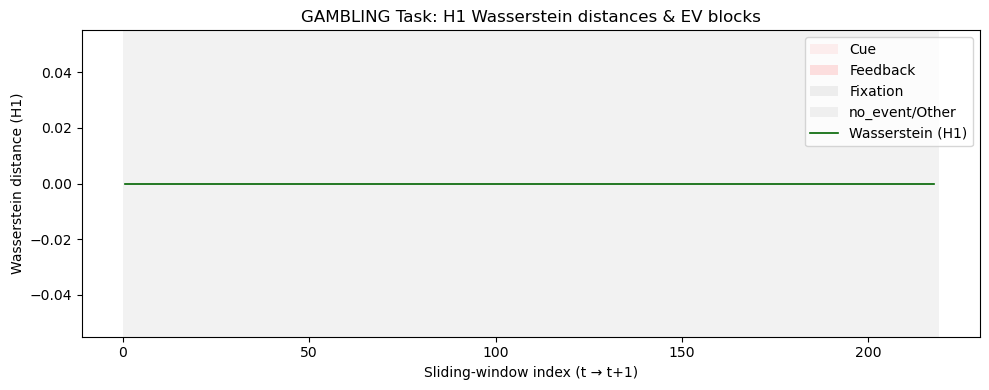

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 4))

# H1 Wasserstein 거리 시계열
x = np.arange(len(wdistances_H1)) + 0.5
ax.plot(x, wdistances_H1, color="darkgreen", linewidth=1.2, label="Wasserstein (H1)")
ax.set_ylabel("Wasserstein distance (H1)")
ax.set_xlabel("Sliding-window index (t → t+1)")

# 배경 색칠: 각 윈도우 별 trial_type
# EV 블록 이름이 예시와 다를 수 있으니, 필요한 경우 수정하세요.
block_colors = {
    "Cue":       (1.0, 0.8, 0.8, 0.3),
    "Feedback":  (1.0, 0.6, 0.6, 0.3),
    "Fixation":  (0.8, 0.8, 0.8, 0.3),
}
for t in range(n_windows):
    label = window_labels[t]
    color = block_colors.get(label, (0.5, 0.5, 0.5, 0.1))
    ax.axvspan(t, t + 1, facecolor=color, edgecolor=None)

# 범례 추가
legend_patches = [
    Patch(facecolor=(1.0, 0.8, 0.8, 0.3), label="Cue"),
    Patch(facecolor=(1.0, 0.6, 0.6, 0.3), label="Feedback"),
    Patch(facecolor=(0.8, 0.8, 0.8, 0.3), label="Fixation"),
    Patch(facecolor=(0.5, 0.5, 0.5, 0.1), label="no_event/Other")
]
ax.legend(handles=legend_patches + [ax.lines[0]], loc="upper right")
ax.set_title(f"{TASK} Task: H1 Wasserstein distances & EV blocks")

plt.tight_layout()
plt.show()